# **🚗 Project Overview**

The goal of this project is to predict the selling price of cars based on various features such as brand, year of manufacture, mileage, fuel type, transmission type, engine size, and other relevant characteristics.
By leveraging machine learning algorithms, this project aims to build a robust and accurate model that can estimate a car’s market value efficiently.

The motivation behind this project is to help buyers, sellers, and dealerships make informed decisions by providing data-driven price predictions. It reduces manual guesswork, eliminates human bias, and ensures transparency in the car resale market.

## SECTION -1: IMPORTING LIBRARIES

In [119]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import joblib

#sklearn Imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor


In [120]:
# Try importing XGBoost

try:
  import xgboost as xgb
  have_xgb=True
except:
  have_xgb=False

In [121]:
sns.set_theme(style='whitegrid', palette='pastel')

## SECTION 2: LOAD DATASET

In [122]:
#Uploading Dataset
df=pd.read_csv('Car.csv')

In [123]:
#Quick look into the dataset

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [124]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## SECTION 3: DATA CLEANING

In [125]:
#Data Cleaning

#Dropping Duplicates Items
df.drop_duplicates(inplace=True)

#Dropping Irrelevant columns(id and name)
df.drop(columns=['car_ID','CarName'], errors='ignore', inplace=True)

#Checking Missing values
print("Missing Values: ",df.isnull().sum())

Missing Values:  symboling           0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


## SECTION 4: EXPLORATORY DATA ANALYSIS (EDA)

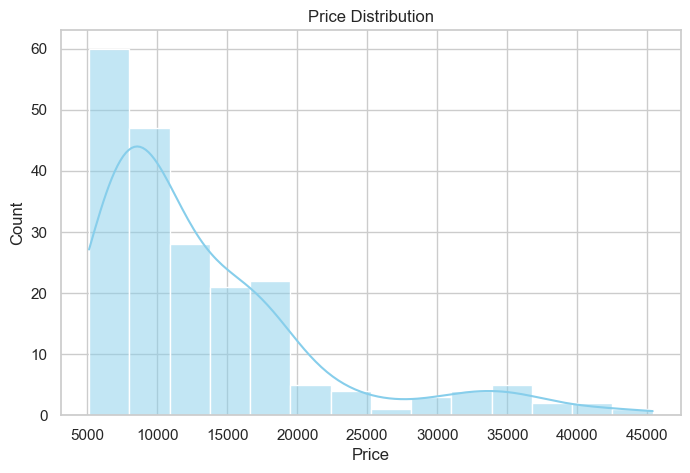

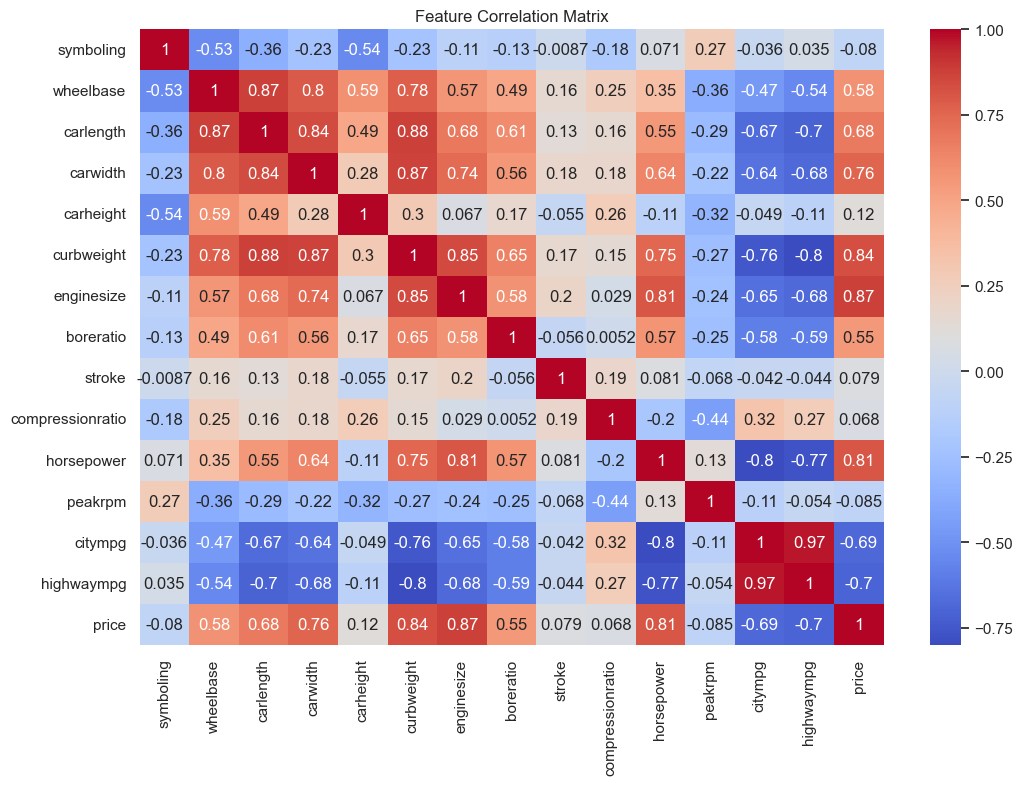

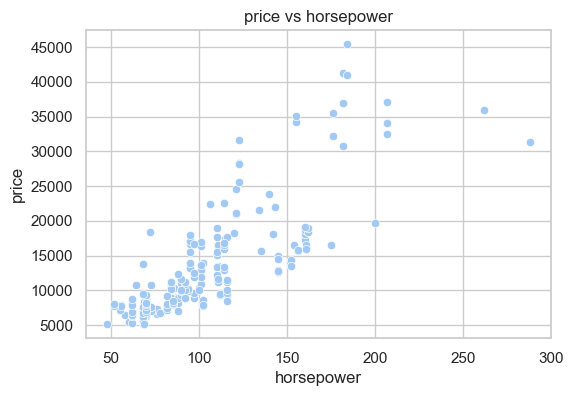

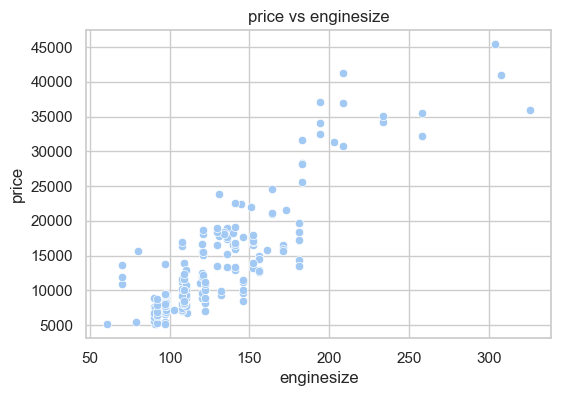

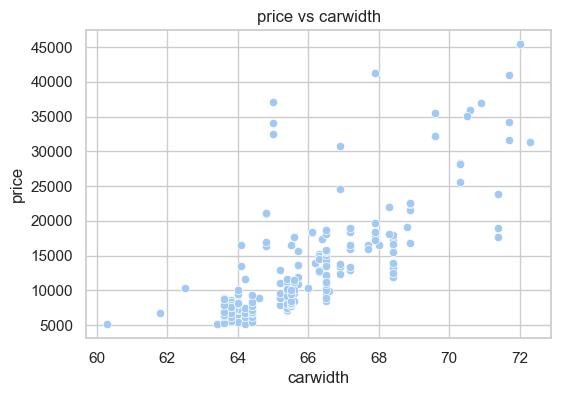

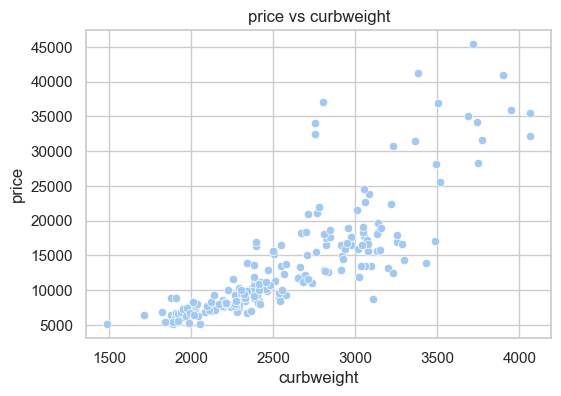

In [126]:
# Target Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'],kde=True, color='skyblue')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.show()
print("\n\n\n")

#Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()
print("\n\n\n")


# Scatter Plot for important feature
imp_feature=['horsepower','enginesize','carwidth','curbweight']
for col in imp_feature:
  if col in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['price'])
    plt.title(f'price vs {col}')
    plt.show()
    print("\n\n\n")

## SECTION 5: FEATURE ENGINEERING

In [127]:
# One-hot encoding categorical variable

df_encode = pd.get_dummies(df, drop_first=True)

# Separate features and target (keep X as a DataFrame for now so we can save column names)
X = df_encode.drop('price', axis=1)
y = df_encode['price']

# Save feature names before scaling (important: X will become a numpy array after scaling)
import json
feature_names = X.columns.tolist()  # Get all column names
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Save Scaler for deployment (use .pkl extension to match the app loader)
joblib.dump(scaler, 'scaler_joblib.pkl')

['scaler_joblib.pkl']

## SECTION 6: TRAIN TEST SPLIT

In [128]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)
print("Train shape: ",X_train.shape, "Test shape: ",X_test.shape)

Train shape:  (164, 43) Test shape:  (41, 43)


## SECTION 7: DEFINE EVALUATION FUNCTON

In [129]:
def evaluate_model(y_true,y_pred,model_name):
  r2=r2_score(y_true,y_pred)
  rmse=np.sqrt(mean_squared_error(y_true, y_pred))
  mae=mean_absolute_error(y_true,y_pred)
  print(f"{model_name}->R²: {r2:.4f} | RMSE: {rmse: .2f}  | MAE: {mae:.2f}")
  return {"r2": r2,"rmse": rmse,"mae": mae}


# dictionary to store result
results={}

## SAVING FEATURES NAME

In [130]:
# Save feature names
import json
# X_train is a numpy array after scaling, so it has no .columns attribute
# Use the previously created `feature_names` (before scaling) if available,
# otherwise derive from df_encode (all features except the target 'price').
try:
    feature_names_list = feature_names
except NameError:
    feature_names_list = df_encode.drop('price', axis=1).columns.tolist()
with open('feature_names.json', 'w') as f:
    json.dump(feature_names_list, f)
print(f"Saved {len(feature_names_list)} feature names to 'feature_names.json'")


Saved 43 feature names to 'feature_names.json'


## SECTION 8: MODEL BUILDING

In [131]:
#1. Linear Regression

lr=LinearRegression()
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)
results['Linear Regression']=evaluate_model(y_test,lr_pred,"Linear Regression")


#2. Ridge Regression

ridge=Ridge()
ridge.fit(X_train,y_train)
ridge_pred=ridge.predict(X_test)
results['Ridge Regression']=evaluate_model(y_test,ridge_pred,"Ridge Regression")


#3 Lasso Regression

lasso=Lasso(alpha=0.001,max_iter=10000)
lasso.fit(X_train,y_train)
lasso_pred=lasso.predict(X_test)
results['Lasso Regression']=evaluate_model(y_test,lasso_pred,"Lasso Regression")


# 4 Random Forest

rf=RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
results['Random Forest']=evaluate_model(y_test,rf_pred,"Random Forest")


#XG Boost
if have_xgb:
  xgb_model=xgb.XGBRegressor(objective='reg:squarederror', random_state=42,n_estimators=200)
  xgb_model.fit(X_train,y_train)
  xgb_pred=xgb_model.predict(X_test)
  results['XGBoost']=evaluate_model(y_test,xgb_pred,"XGBoost")


#Display Results
results_df=pd.DataFrame(results).T
display(results_df.sort_values(by='r2',ascending=False))

Linear Regression->R²: 0.8926 | RMSE:  2912.39  | MAE: 2089.38
Ridge Regression->R²: 0.8852 | RMSE:  3010.19  | MAE: 2108.60


Lasso Regression->R²: 0.8926 | RMSE:  2912.39  | MAE: 2089.38
Random Forest->R²: 0.9585 | RMSE:  1810.36  | MAE: 1231.88
Random Forest->R²: 0.9585 | RMSE:  1810.36  | MAE: 1231.88
XGBoost->R²: 0.9342 | RMSE:  2279.55  | MAE: 1573.77
XGBoost->R²: 0.9342 | RMSE:  2279.55  | MAE: 1573.77


,r2,rmse,mae
Random Forest,0.958484,1810.362758,1231.881699
XGBoost,0.934177,2279.552535,1573.770198
Linear Regression,0.892557,2912.388793,2089.382729
Lasso Regression,0.892556,2912.393557,2089.382135
Ridge Regression,0.885219,3010.192857,2108.602174


## SECTION 9: FEATURE IMPORTANCE

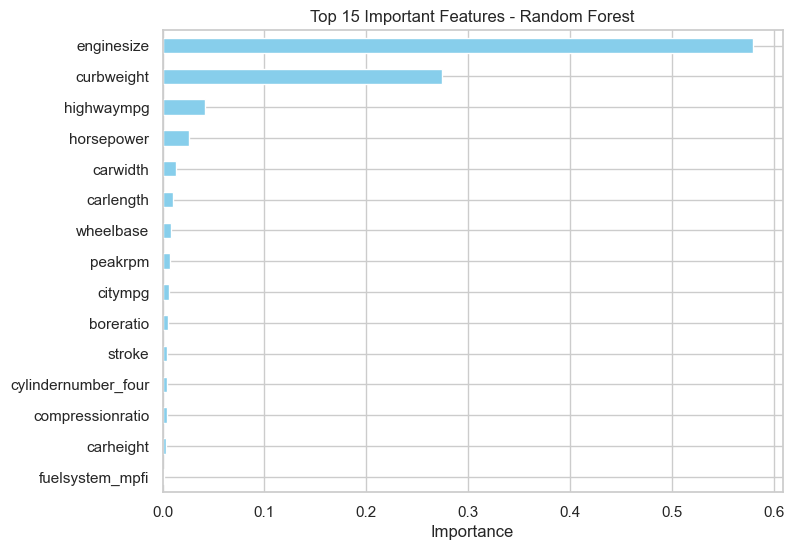

In [132]:
# Save feature names before scaling
feature_names = df_encode.drop('price', axis=1).columns  # all features except target

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encode.drop('price', axis=1))  # scale features

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df_encode['price'], test_size=0.2, random_state=42)

# Random Forest feature importance
feat_imp = pd.Series(rf.feature_importances_, index=feature_names)
top_features = feat_imp.nlargest(15)
plt.figure(figsize=(8,6))
top_features[::-1].plot(kind='barh', color='skyblue')
plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Importance")
plt.show()


## SECTION 10: HYPERPARAMENER TUNING (RANDOM FOREST)

In [133]:
param_grid={
    'n_estimators': [100,200,300],
    'max_depth':[None,6,10,15],
    'min_samples_split': [2,5,10],
    'min_samples_leaf' : [1,2,4]
}

grid=GridSearchCV(RandomForestRegressor(random_state=42),param_grid, cv=4, scoring='r2', n_jobs=-1, verbose=1)
grid.fit(X_train,y_train)

print("Best HyperParameters: ", grid.best_params_)
best_rf=grid.best_estimator_

#Evaluate tuned model
best_pred=best_rf.predict(X_test)
results['Random Forest Tuned']=evaluate_model(y_test,best_pred,"Random Forest Tuned")

Fitting 4 folds for each of 108 candidates, totalling 432 fits
Best HyperParameters:  {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Tuned->R²: 0.9584 | RMSE:  1811.14  | MAE: 1233.00
Best HyperParameters:  {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Tuned->R²: 0.9584 | RMSE:  1811.14  | MAE: 1233.00


## SECTION 11: RESIDUAL PLOT

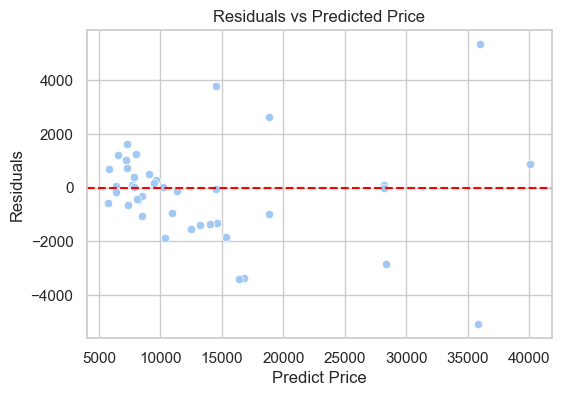

In [134]:
residuals=y_test-best_pred
plt.figure(figsize=(6,4))
sns.scatterplot(x=best_pred, y=residuals)
plt.axhline(0,color='red', linestyle='--')
plt.xlabel("Predict Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Price")
plt.show()

## SECTION 12: SAVE MODEL

In [135]:
joblib.dump(best_rf,"Car_price_rf_model.pkl")
print("Saved model as 'car_price_rf_model.pkl' and scaler as 'scaler_joblib.pkl'")

Saved model as 'car_price_rf_model.pkl' and scaler as 'scaler_joblib.pkl'


## SECTION 13: FINAL SUMMARY

In [136]:
print("=== Final Model Results ===")
display(pd.DataFrame(results).T.sort_values(by='r2', ascending=False))

=== Final Model Results ===


,r2,rmse,mae
Random Forest,0.958484,1810.362758,1231.881699
Random Forest Tuned,0.958449,1811.143315,1233.004931
XGBoost,0.934177,2279.552535,1573.770198
Linear Regression,0.892557,2912.388793,2089.382729
Lasso Regression,0.892556,2912.393557,2089.382135
Ridge Regression,0.885219,3010.192857,2108.602174
